# Results Visualization — INX Future Inc. Employee Performance
**IABAC Certified Data Scientist — Project Code: 10281**

Consolidated visual summary of both trained models (Hiring Model, Diagnostic Model) and the
department/EDA results, for inclusion in the final project report.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, json

sns.set_style('whitegrid')

df = pd.read_csv('../../data/processed/employee_performance_clean.csv')
with open('../../models/model_metadata.json') as f:
    meta = json.load(f)

hiring_model = joblib.load('../../models/hiring_model.pkl')
hiring_features = joblib.load('../../models/hiring_feature_names.pkl')
diagnostic_model = joblib.load('../../models/diagnostic_model.pkl')
diagnostic_features = joblib.load('../../models/diagnostic_feature_names.pkl')
meta

{'hiring_model': {'model_name': 'XGBoost',
  'needs_scaling': False,
  'label_offset': 2,
  'test_accuracy': 0.4166666666666667,
  'macro_f1': 0.3309447297733638,
  'cv_macro_f1': 0.3693237619690999,
  'best_params': {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100},
  'feature_columns': ['Age',
   'Gender',
   'EducationBackground',
   'MaritalStatus',
   'EmpDepartment',
   'EmpJobRole',
   'EmpJobLevel',
   'BusinessTravelFrequency',
   'DistanceFromHome',
   'EmpEducationLevel',
   'NumCompaniesWorked',
   'TotalWorkExperienceInYears'],
  'top_predictors': ['EmpDepartment', 'EmpJobRole', 'NumCompaniesWorked'],
  'selection_criterion': 'CV macro-F1 (5-fold, stratified)',
  'class_weighting': 'balanced (native class_weight or compute_sample_weight)'},
 'diagnostic_model': {'model_name': 'Random Forest',
  'needs_scaling': False,
  'label_offset': 0,
  'test_accuracy': 0.9416666666666667,
  'macro_f1': 0.9009898624617874,
  'cv_macro_f1': 0.8956883945303538,
  'best_params'

## 1. Model Performance Snapshot — Both Models

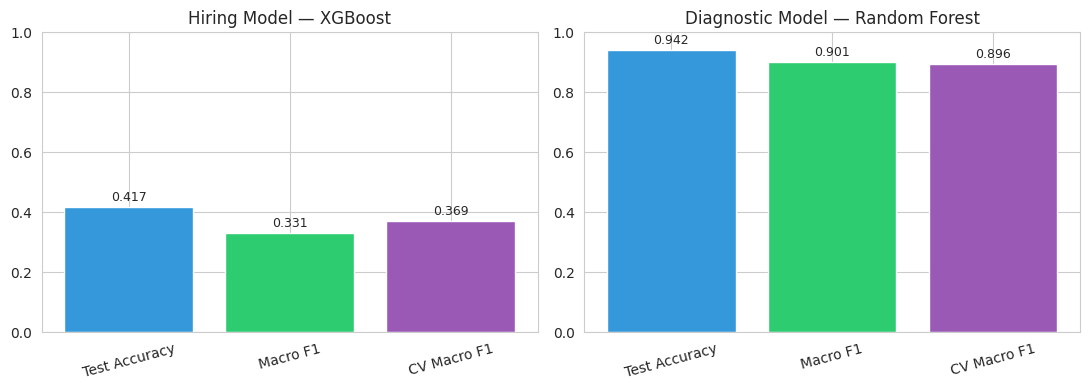

Note: the Hiring Model's lower scores are expected and explained in train_model.ipynb —
it deliberately excludes tenure/satisfaction/compensation features not knowable about a
candidate, and is still selected/evaluated by macro-F1 against a majority-class baseline.


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(11,4))
for ax, key, title in [(axes[0], 'hiring_model', 'Hiring Model'), (axes[1], 'diagnostic_model', 'Diagnostic Model')]:
    m = {'Test Accuracy': meta[key]['test_accuracy'], 'Macro F1': meta[key]['macro_f1'], 'CV Macro F1': meta[key]['cv_macro_f1']}
    bars = ax.bar(m.keys(), m.values(), color=['#3498db', '#2ecc71', '#9b59b6'])
    ax.set_ylim(0, 1)
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.02, f'{b.get_height():.3f}', ha='center', fontsize=9)
    ax.set_title(f"{title} — {meta[key]['model_name']}")
    ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.savefig('../../references/final_model_performance.png', dpi=120)
plt.show()

print('Note: the Hiring Model\'s lower scores are expected and explained in train_model.ipynb —')
print('it deliberately excludes tenure/satisfaction/compensation features not knowable about a')
print('candidate, and is still selected/evaluated by macro-F1 against a majority-class baseline.')

## 2. Department-wise Performance (Final View)

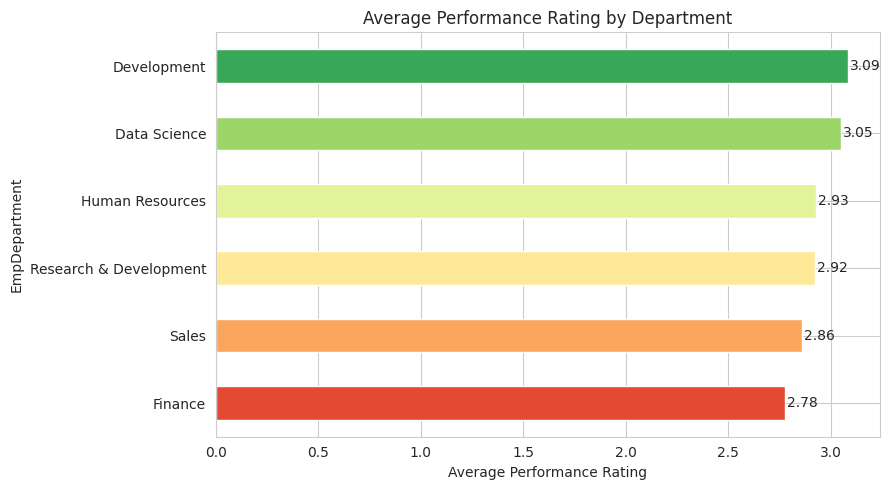

EmpDepartment
Development               3.086
Data Science              3.050
Human Resources           2.926
Research & Development    2.921
Sales                     2.861
Finance                   2.776
Name: PerformanceRating, dtype: float64


In [3]:
dept_perf = df.groupby('EmpDepartment')['PerformanceRating'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9,5))
colors = sns.color_palette('RdYlGn', len(dept_perf))
dept_perf.sort_values().plot(kind='barh', color=colors, ax=ax)
ax.set_title('Average Performance Rating by Department')
ax.set_xlabel('Average Performance Rating')
for i, v in enumerate(dept_perf.sort_values()):
    ax.text(v + 0.01, i, f'{v:.2f}', va='center')
plt.tight_layout()
plt.savefig('../../references/final_department_performance.png', dpi=120)
plt.show()

print(dept_perf.round(3))

## 3. Top 3 Factors Affecting Employee Performance (Diagnostic Model)

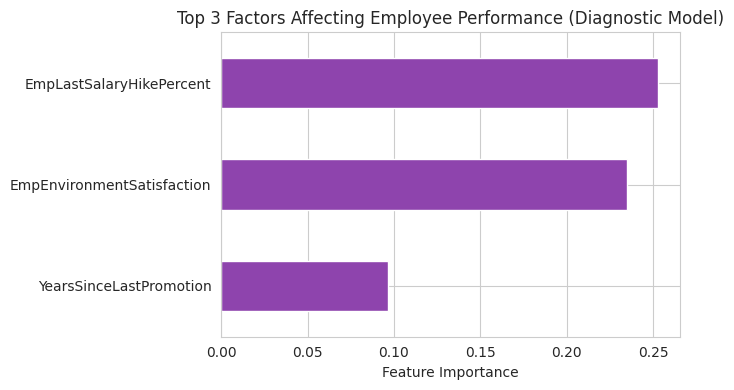

Top 3 factors (Diagnostic Model, current workforce):
1. EmpLastSalaryHikePercent
2. EmpEnvironmentSatisfaction
3. YearsSinceLastPromotion


In [4]:
top3 = meta['diagnostic_model']['top_3_factors']
importances = pd.Series(diagnostic_model.feature_importances_, index=diagnostic_features).loc[top3]

fig, ax = plt.subplots(figsize=(7,4))
importances.sort_values().plot(kind='barh', color='#8e44ad', ax=ax)
ax.set_title('Top 3 Factors Affecting Employee Performance (Diagnostic Model)')
ax.set_xlabel('Feature Importance')
plt.tight_layout()
plt.savefig('../../references/top3_factors.png', dpi=120)
plt.show()

print('Top 3 factors (Diagnostic Model, current workforce):')
for i, f in enumerate(top3, 1):
    print(f'{i}. {f}')

## 4. Full Feature Importance — Both Models

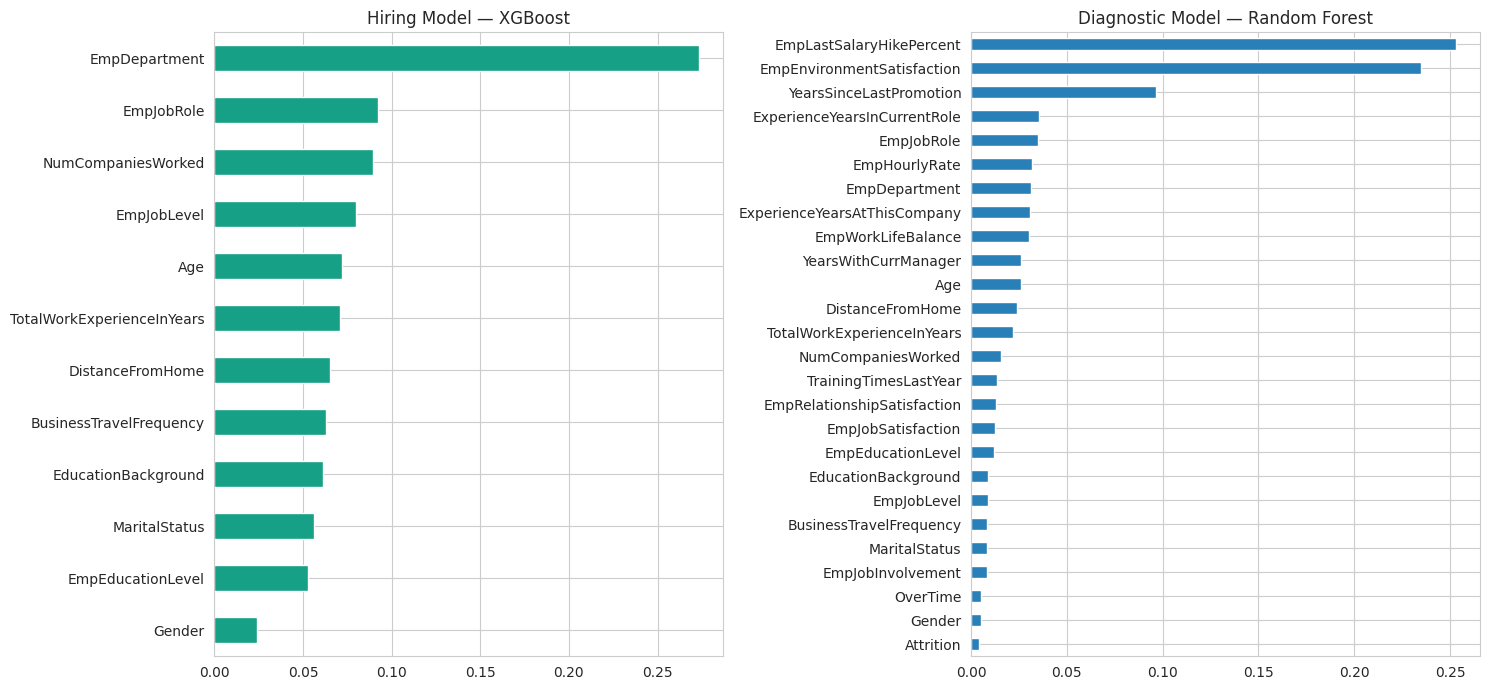

In [5]:
hiring_importances = pd.Series(hiring_model.feature_importances_, index=hiring_features).sort_values(ascending=False) \
    if hasattr(hiring_model, 'feature_importances_') else None
diag_importances = pd.Series(diagnostic_model.feature_importances_, index=diagnostic_features).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15,7))
if hiring_importances is not None:
    hiring_importances.sort_values().plot(kind='barh', ax=axes[0], color='#16a085')
    axes[0].set_title(f"Hiring Model — {meta['hiring_model']['model_name']}")
diag_importances.sort_values().plot(kind='barh', ax=axes[1], color='#2980b9')
axes[1].set_title(f"Diagnostic Model — {meta['diagnostic_model']['model_name']}")
plt.tight_layout()
plt.savefig('../../references/full_feature_importance.png', dpi=120)
plt.show()

## 5. Overtime vs. Performance (Corrected)

OverTime
No     2.932
Yes    2.989
Name: PerformanceRating, dtype: float64


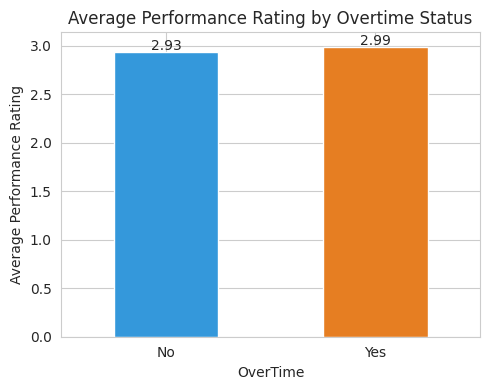


Employees who work overtime have a SLIGHTLY HIGHER average performance rating (2.99) than those who do not (2.93).
This corrects an earlier draft of this analysis, which stated the opposite direction.


In [6]:
overtime_perf = df.groupby('OverTime')['PerformanceRating'].mean()
print(overtime_perf.round(3))

fig, ax = plt.subplots(figsize=(5,4))
overtime_perf.plot(kind='bar', color=['#3498db', '#e67e22'], ax=ax)
ax.set_title('Average Performance Rating by Overtime Status')
ax.set_ylabel('Average Performance Rating')
ax.set_xticklabels(overtime_perf.index, rotation=0)
for i, v in enumerate(overtime_perf):
    ax.text(i, v + 0.02, f'{v:.2f}', ha='center')
plt.tight_layout()
plt.savefig('../../references/overtime_performance.png', dpi=120)
plt.show()

print()
print('Employees who work overtime have a SLIGHTLY HIGHER average performance rating',
      f'({overtime_perf["Yes"]:.2f}) than those who do not ({overtime_perf["No"]:.2f}).')
print('This corrects an earlier draft of this analysis, which stated the opposite direction.')

## Summary

This notebook consolidates the final results visuals:
1. Performance snapshot for **both** models, with the Hiring Model's modest scores explained
   rather than hidden.
2. Department-wise average performance ranking.
3. Top 3 factors driving performance, from the Diagnostic Model.
4. Full feature-importance ranking for both models.
5. The corrected overtime-vs-performance relationship (overtime workers rate *slightly higher*,
   not lower).

All charts are saved as PNGs to `references/` for direct reuse in the written report.
